In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from collections import Counter

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


## Kernel Content

1. [Load Data](#1)
1. [Data Analysis](#2)
1. [Basic Data Analysis](#3)
1. [Random Forest](#4)
1. [Test](#5)

<a id=1></a>
## Data Read

In [2]:
df_train = pd.read_csv("/kaggle/input/titanic/train.csv")
df_test = pd.read_csv("/kaggle/input/titanic/test.csv")
submission = pd.read_csv("/kaggle/input/titanic/gender_submission.csv")

In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## The columns of the data set

1. PassengerId
1. Survived: 0->Died 1->Alive
1. Pclass: 1-> 1st Grade 2-> 2nd Grade 3-> 3rd Grade 
1. Name
1. Sex
1. Age 
1. SibSp: (number of) Siblings/Spouses
1. Parch: (number of) Parent/Children
1. Ticket
1. Fare
1. Cabin
1. Embarked: C->Cherbourg, Q->Queenstown, S->Southampton

## Variable Types
1. Categorial Variable
    Survived, Sex, Pclass, Embarked, Cabin, Name, Sibsn, Ticket and Parch
2. Numerical Variable 
    Fare, Age, PassengerId

In [4]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* int64      [PassengerId, Survived, Pclass, SibSp, Parch]
* float64                                      [Age, Fare]
* object              [Name, Sex, Ticket, Cabin, Embarked]

<a id=2></a>
## Data Analysis 




## Univariate Variable Analysis

### Categorical Variables

1. Survived
1. Sex 
1. Pclass 
1. Embarked
1. Cabin
1. Name 
1. Sibsn 
1. Parch
1. Ticket


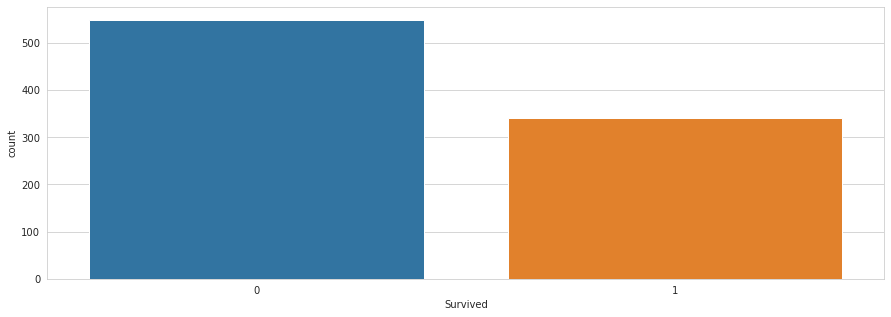

In [7]:
plt.figure(figsize=(15,5))
sns.countplot(df_train.Survived);

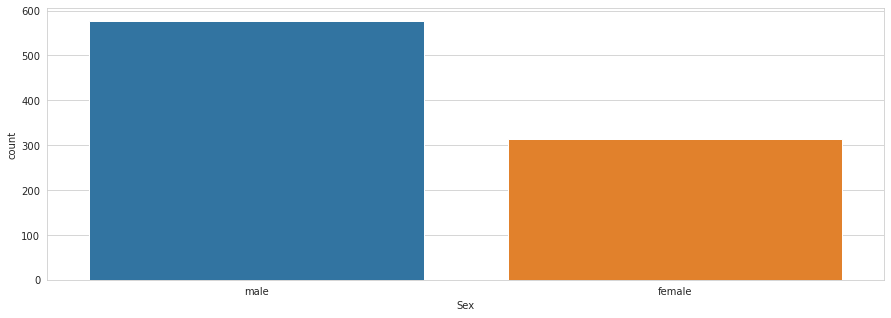

In [8]:
plt.figure(figsize=(15,5))
sns.countplot(df_train.Sex);

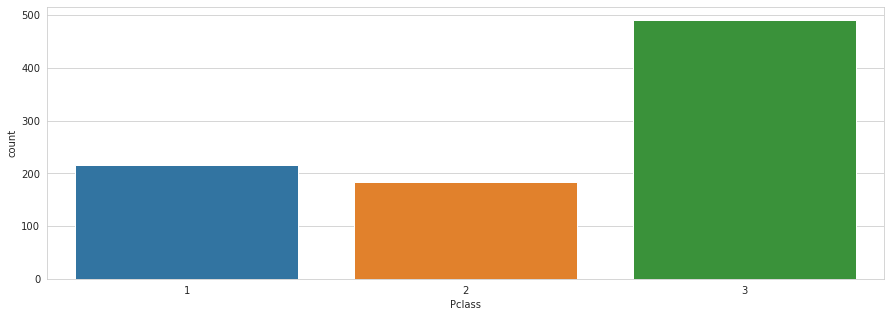

In [9]:
plt.figure(figsize=(15,5))
sns.countplot(df_train.Pclass);

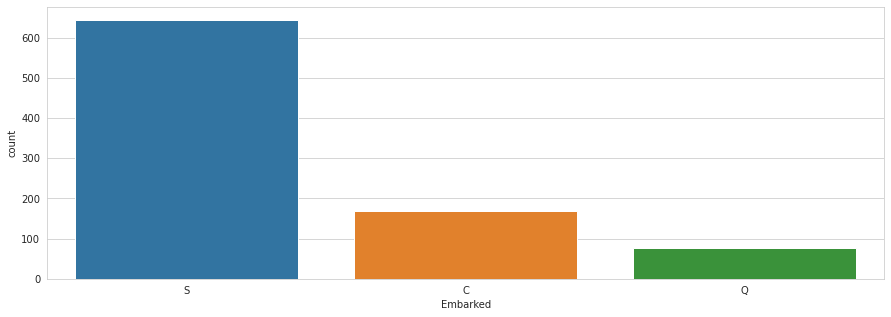

In [10]:
plt.figure(figsize=(15,5))
sns.countplot(df_train.Embarked);

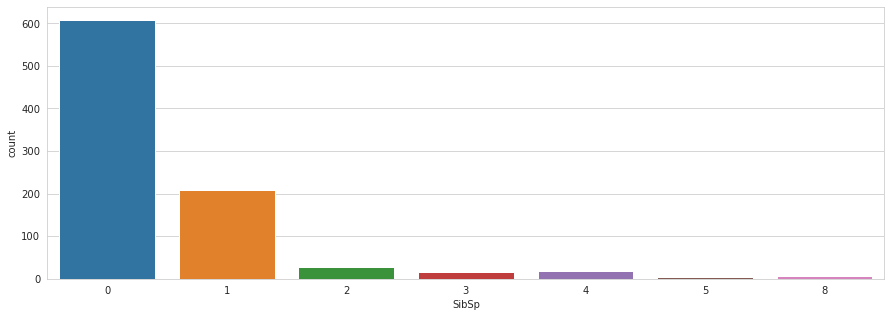

In [11]:
plt.figure(figsize=(15,5))
sns.countplot(df_train.SibSp);

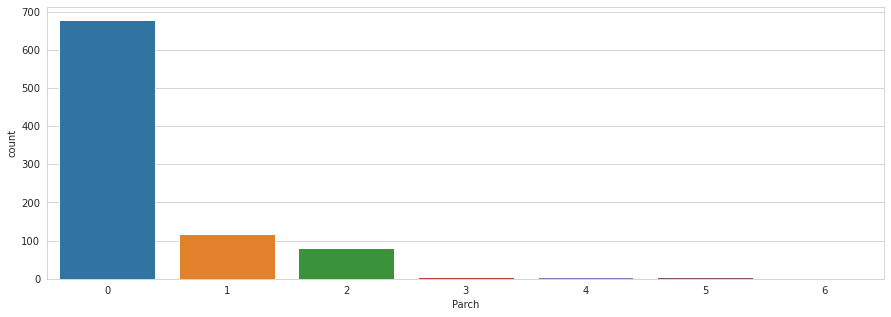

In [12]:
plt.figure(figsize=(15,5))
sns.countplot(df_train.Parch);

The Name, Ticket and Cabin columns have unique values, so no visualization has been made.

### Numerical Variabels

1. Fare
1. Age 
1. PassengerId (Not visualized)

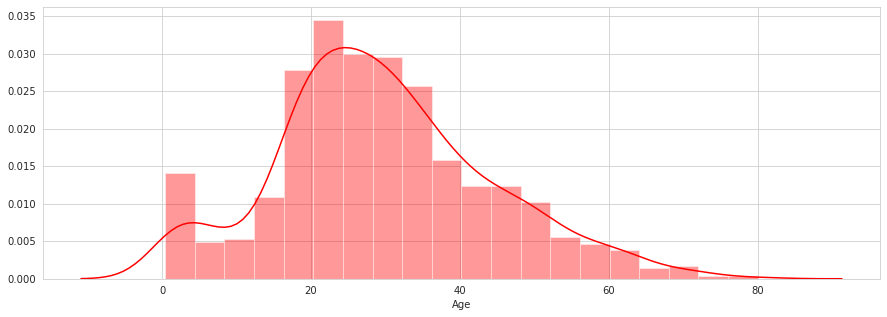

In [13]:
plt.figure(figsize=(15,5))
sns.distplot(df_train.Age, hist=True, kde=True, color='r');
plt.show()

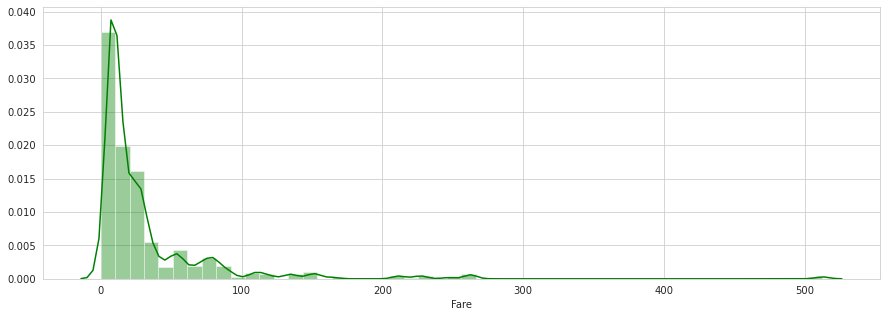

In [14]:
plt.figure(figsize=(15,5))
sns.distplot(df_train.Fare, hist=True, kde=True, color='g')
plt.show()

<a id=3></a>
## Basic Data Analysis

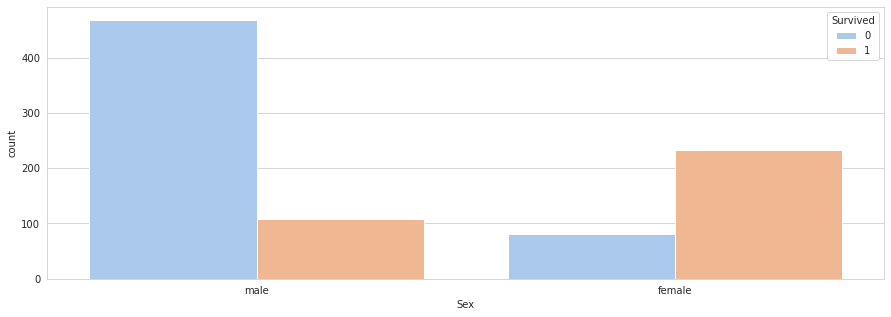

In [15]:
plt.figure(figsize=(15,5))
sns.countplot(df_train.Sex, hue=df_train.Survived, palette='pastel');

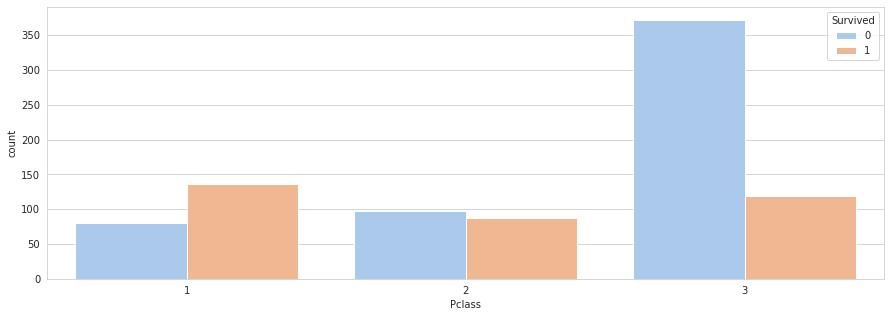

In [16]:
plt.figure(figsize=(15,5))
sns.countplot(df_train.Pclass, hue=df_train.Survived, palette='pastel');

### Missing Values

In [17]:
df = pd.concat([df_train, df_test])

In [18]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [19]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


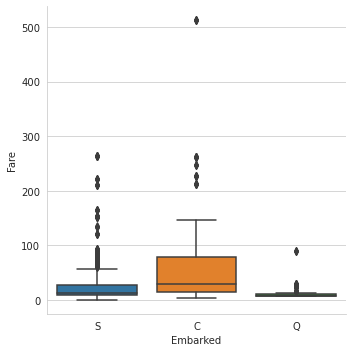

In [20]:
sns.catplot(x="Embarked", y="Fare", kind="box", data=df);

In [21]:
df['Embarked'] = df["Embarked"].fillna("C")

In [22]:
df[df['Fare'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [23]:
df['Fare'] = df["Fare"].fillna(df.Fare.mean())

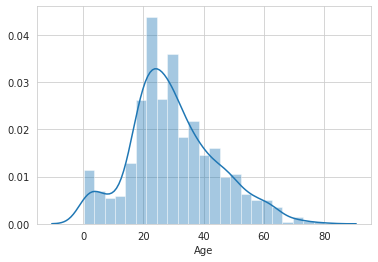

In [24]:
sns.distplot(df.Age);

In [25]:
df.Age.mean()

29.881137667304014

In [26]:
df.Age.median()

28.0

In [27]:
df['Age'] = df["Age"].fillna(df.Age.mean())

In [28]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
df = df.drop(['Name', "PassengerId", "Ticket", "Cabin"], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,3,male,22.0,1,0,7.2500,S
1,1.0,1,female,38.0,1,0,71.2833,C
2,1.0,3,female,26.0,0,0,7.9250,S
3,1.0,1,female,35.0,1,0,53.1000,S
4,0.0,3,male,35.0,0,0,8.0500,S


In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df["Sex"])
df['Embarked'] = le.fit_transform(df['Embarked'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,3,1,22.0,1,0,7.2500,2
1,1.0,1,0,38.0,1,0,71.2833,0
2,1.0,3,0,26.0,0,0,7.9250,2
3,1.0,1,0,35.0,1,0,53.1000,2
4,0.0,3,1,35.0,0,0,8.0500,2


In [31]:
train = df.iloc[0: (df.shape[0] - df_test.shape[0])]
test = df.iloc[df_train.shape[0]:]

In [32]:
X = train.drop(['Survived'], axis=1)
y = train.Survived

<a id=4></a>
## Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [34]:
rf_params = {'n_estimators': [400,500,600,700],
            'max_features': [5,6,7,8,9,10],
            'min_samples_split':[5,6,7,8,9,10]}

In [35]:
from sklearn.model_selection import GridSearchCV
rf_cv_model = GridSearchCV(rf, rf_params, cv=21, n_jobs=-1, verbose=1).fit(X, y)


Fitting 21 folds for each of 144 candidates, totalling 3024 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   23.9s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed: 12.9min
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed: 16.6min
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed: 18.6min
[Parallel(n_jobs=-1)]: Done 3024 out of 3024 | elapsed: 20.4min finished


In [36]:
rf_cv_model

GridSearchCV(cv=21, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_features': [5, 6, 7, 8, 9, 10],
                         'min_samples_split': [5, 6, 7, 8, 9, 10],
                         'n_estimators': [400, 500, 600, 700]},
             verbose=1)

In [37]:
best_params = rf_cv_model.best_params_
print(best_params)

{'max_features': 5, 'min_samples_split': 6, 'n_estimators': 700}


In [38]:
rf = RandomForestClassifier(
    max_features=best_params['max_features'], 
    min_samples_split=best_params['min_samples_split'], 
    n_estimators=best_params['n_estimators']
).fit(X, y)

In [39]:
y_pred_rf = rf.predict(X)

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred_rf)

0.9304152637485971

In [41]:
rf.feature_importances_

array([0.1109931 , 0.33822184, 0.217313  , 0.04412213, 0.02410169,
       0.23663385, 0.0286144 ])

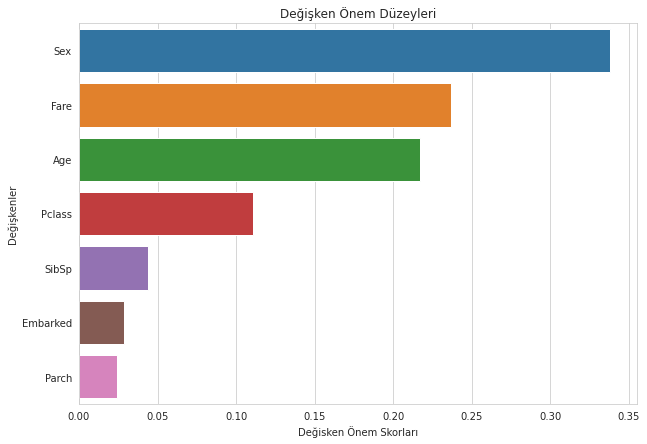

In [42]:
feature_imp = pd.Series(rf.feature_importances_,
                       index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Değisken Önem Skorları')
plt.ylabel('Değişkenler')
plt.title('Değişken Önem Düzeyleri')
plt.show()

In [43]:
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, cv=7).mean()

0.826121344206974

In [44]:
from imblearn.metrics import classification_report_imbalanced, sensitivity_specificity_support
print('sensitivity and specificity:', sensitivity_specificity_support(y, y_pred_rf, average='micro', labels=pd.unique(df_train.Survived)))
print(classification_report_imbalanced(y, y_pred_rf))

sensitivity and specificity: (0.9304152637485971, 0.9304152637485971, None)
                   pre       rec       spe        f1       geo       iba       sup

        0.0       0.92      0.97      0.87      0.94      0.92      0.85       549
        1.0       0.94      0.87      0.97      0.91      0.92      0.84       342

avg / total       0.93      0.93      0.91      0.93      0.92      0.85       891



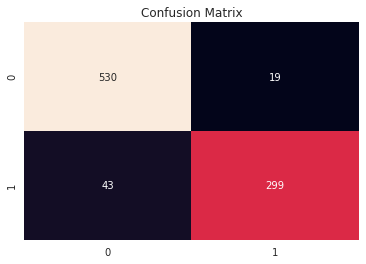

In [45]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.title('Confusion Matrix')
plt.savefig('con_mat')
plt.show()

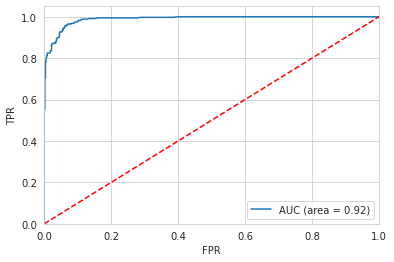

In [46]:
from sklearn.metrics import roc_auc_score, roc_curve
rf_roc_auc = roc_auc_score(y, rf.predict(X))
fpr , tpr, thresholds = roc_curve(y, rf.predict_proba(X)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='AUC (area = %0.2f)' % rf_roc_auc)
plt.plot([0,1], [0,1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='lower right')
plt.show()

<a id=5></a>
## Test

In [47]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [48]:
test.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,NaN,3,1,34.5,0,0,7.8292,1
1,NaN,3,0,47.0,1,0,7.0000,2
2,NaN,2,1,62.0,0,0,9.6875,1
3,NaN,3,1,27.0,0,0,8.6625,2
4,NaN,3,0,22.0,1,1,12.2875,2


In [49]:
test = test.drop(['Survived'], axis=1)

In [50]:
submission = df_test.PassengerId.copy().to_frame()
predictions = rf.predict(test)

In [51]:
predictions = [int(i) for i in predictions]
submission['Survived'] = predictions

In [52]:
submission.to_csv("submission.csv", index = False)